# Projeto: Análise de Performance Comercial e Insights de Vendas (2015-2020)
## 1. Introdução
Este projeto tem como objetivo realizar uma análise exploratória de dados (EDA) e o desenvolvimento de um dashboard interativo para monitorar os resultados de vendas. O foco é transformar dados brutos em inteligência de negócio, facilitando a tomada de decisão.

## 2. Entidades e Atributos
Para entender o fenômeno das vendas, analisaremos cinco pilares fundamentais (atributos):

#### Data: A dimensão temporal. Permite identificar sazonalidade (meses que vendem mais) e tendências ao longo dos anos.

#### Vendedor: O capital humano. Essencial para analisar o ranking de performance e produtividade da equipe.

#### Produto: O objeto de venda. Nos permite entender qual item tem maior saída e, cruzando com a base de índices, identificar quais Marcas e Grifes dominam o faturamento.

#### Forma_Pgto: O comportamento financeiro. Identifica as preferências do cliente (Cartão, Boleto ou Dinheiro), o que impacta o fluxo de caixa.

#### Preço: O valor monetário. É a base para o cálculo de faturamento total, ticket médio e margens de receita.

In [38]:
import pandas as pd
import numpy as np

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
import plotly.express as px
import os

In [41]:
df = pd.read_excel('Base Completa.xlsx')

In [42]:
# Ver as 5 primeiras linhas
df.head()


,Data,Vendedor,Produto,Forma_Pgto,Preço
0,2015-01-01,Diana Martins,Produto E,Cartão de Crédito,709.5
1,2015-01-01,Clara Nunes,Produto F,Cartão de Crédito,478.5
2,2015-01-01,Camila Souza,Produto H,Cartão de Crédito,396.0
3,2015-01-02,Camila Souza,Produto F,Cartão de Crédito,478.5
4,2015-01-02,Clara Nunes,Produto J,Cartão de Crédito,66.0


In [43]:
# Ver estrutura da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6199 entries, 0 to 6198
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        6199 non-null   datetime64[ns]
 1   Vendedor    6199 non-null   object        
 2   Produto     6199 non-null   object        
 3   Forma_Pgto  6199 non-null   object        
 4   Preço       6199 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 242.3+ KB


In [44]:
# Estatísticas numéricas
df.describe()


,Data,Preço
count,6199,6199.0
mean,2017-12-23 19:56:19.319245056,447.9
min,2015-01-01 00:00:00,66.0
25%,2016-06-15 00:00:00,165.0
50%,2017-12-29 00:00:00,445.5
75%,2019-06-16 12:00:00,709.5
max,2020-12-31 00:00:00,759.0
std,NaN,247.1


A base de dados possui 6.199 registros de vendas entre os anos de 2015 e 2020.
O preço das vendas varia entre R$ 66 e R$ 759, com preço médio de R$ 447,93.
A mediana dos preços é R$ 445,50, indicando que os dados estão bem distribuídos e sem grandes outliers.
A maior parte das vendas está entre R$ 165 e R$ 709,50.

In [45]:
# Ver nomes das colunas
df.columns

Index(['Data', 'Vendedor', 'Produto', 'Forma_Pgto', 'Preço'], dtype='object')

Leitura e Compreensão Inicial dos Dados

Nesta etapa, realizamos a leitura da base de dados utilizando a biblioteca Pandas.
Após a leitura, fazemos uma análise inicial para entender a estrutura dos dados, tipos de variáveis, quantidade de registros e possíveis valores nulos.

As funções utilizadas nesta etapa são:

head() → Visualizar as primeiras linhas da base
info() → Ver tipos de dados e valores nulos
describe() → Ver estatísticas descritivas
columns → Ver nomes das colunas

In [46]:
# Verificando a quantidade de valores nulos em cada coluna
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
Data          0
Vendedor      0
Produto       0
Forma_Pgto    0
Preço         0
dtype: int64


In [47]:
# Verificando os tipos de dados de cada coluna
print("Tipos de dados nas colunas:")
df.info()

Tipos de dados nas colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6199 entries, 0 to 6198
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        6199 non-null   datetime64[ns]
 1   Vendedor    6199 non-null   object        
 2   Produto     6199 non-null   object        
 3   Forma_Pgto  6199 non-null   object        
 4   Preço       6199 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 242.3+ KB


In [48]:
# Imprimindo o nome das colunas
print(df.columns)

Index(['Data', 'Vendedor', 'Produto', 'Forma_Pgto', 'Preço'], dtype='object')


In [49]:
# Renomeando a coluna específica
df = df.rename(columns={'Forma_Pgto': 'Forma_de_pagamento'})

# Verificando se a alteração foi aplicada
print(df.columns)

Index(['Data', 'Vendedor', 'Produto', 'Forma_de_pagamento', 'Preço'], dtype='object')


In [50]:
# Verificando a quantidade de linhas e colunas
print(df.shape)

(6199, 5)


In [51]:
# Gerando a análise descritiva e arredondando para 1 casa decimal
estatisticas = df.describe(include='all').round(1)

# Exibindo o resultado
display(estatisticas)

,Data,Vendedor,Produto,Forma_de_pagamento,Preço
count,6199,6199,6199,6199,6199.0
unique,NaN,6,10,4,NaN
top,NaN,Renato Souza,Produto C,Cartão de Crédito,NaN
freq,NaN,1060,669,3647,NaN
mean,2017-12-23 19:56:19.319245056,NaN,NaN,NaN,447.9
min,2015-01-01 00:00:00,NaN,NaN,NaN,66.0
25%,2016-06-15 00:00:00,NaN,NaN,NaN,165.0
50%,2017-12-29 00:00:00,NaN,NaN,NaN,445.5
75%,2019-06-16 12:00:00,NaN,NaN,NaN,709.5
max,2020-12-31 00:00:00,NaN,NaN,NaN,759.0


In [52]:
df.describe(include='object')

,Vendedor,Produto,Forma_de_pagamento
count,6199,6199,6199
unique,6,10,4
top,Renato Souza,Produto C,Cartão de Crédito
freq,1060,669,3647


Para visualizar a distribuição de uma coluna categórica (como as formas de pagamento), usamos o Histograma.

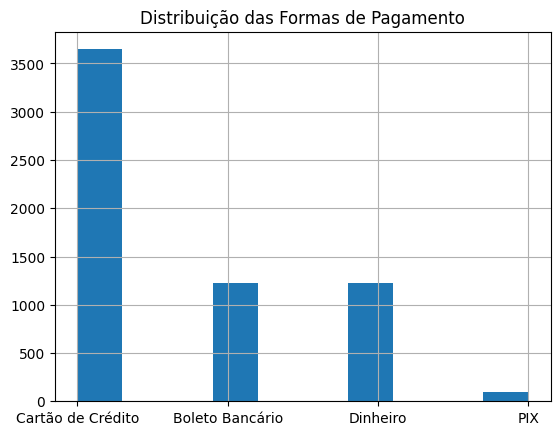

In [53]:

# Definindo o caminho da pasta
caminho_pasta = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos'

# Gerando o histograma
df['Forma_de_pagamento'].hist()
plt.title('Distribuição das Formas de Pagamento')

# Salvando a imagem na pasta específica
# Usamos o nome 'histograma_pagamentos.png'
plt.savefig(f'{caminho_pasta}\\histograma_pagamentos.png')

# Exibindo o gráfico
plt.show()

In [54]:
import plotly.express as px

df_duelo = df[df['Forma_de_pagamento'].isin(['Cartão de Crédito', 'PIX'])]

# Contando os valores do duelo (cartão de crédito X PIX)
df_contagem = df_duelo['Forma_de_pagamento'].value_counts().reset_index()
df_contagem.columns = ['Forma', 'Quantidade']

# Criando o gráfico com o mapeamento de cores correto
fig = px.pie(df_contagem, 
             values='Quantidade', 
             names='Forma',
             title='DOMÍNIO DO CRÉDITO: Oportunidade de Conversão para PIX',
             color_discrete_map={'Cartão de Crédito': 'red', 'PIX': 'blue'}, # Ajustado para PIX
             hole=0.4)

# Ajustes visuais de impacto
fig.update_traces(textinfo='percent+label', pull=[0.1, 0])

# Exibindo o gráfico interativo
fig.show()

#Salvar a versão interativa
fig.write_html(r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\duelo_pagamentos.html')

## Recomendação Estratégica: otimização de margem via PIX

Ao analisarmos o duelo entre **Cartão de Crédito vs. PIX**, a discrepância observada não é apenas um dado estatístico, mas uma **oportunidade latente de aumento de lucro líquido**.

### Diagnóstico do Cenário Atual:
* **Domínio Crítico do Crédito:** A vasta maioria das transações está concentrada em operadoras de cartão, o que implica em taxas de intermediação (MDR) e prazos de recebimento mais longos.
* **Subutilização do PIX:** Apesar de ser um método de liquidação instantânea e baixo custo, sua participação ainda é marginal frente ao potencial da operação.

### Proposta de Ação:
Sugerimos à gestão a implementação imediata de uma **Política de Incentivo ao PIX**, utilizando este gráfico como evidência da necessidade de mudança:

1.  **Desconto Estratégico:** Conceder uma margem de desconto (ex: 3% a 5%) para pagamentos via PIX. O custo desse desconto é frequentemente **menor** que a taxa de antecipação e administração do cartão.
2.  **Melhoria de Fluxo de Caixa:** Estimular o PIX garante capital de giro imediato, reduzindo a dependência de crédito bancário.
3.  **Gamificação no Check-out:** Destacar visualmente a economia gerada ao cliente ao escolher o método instantâneo.

> **Nota Técnica:** A mitigação dessa discrepância visual no gráfico resultará diretamente no fortalecimento do EBITDA da companhia através da redução de despesas financeiras evitáveis.

In [55]:
# Extraindo a data inicial e final
data_inicio = df['Data'].min()
data_fim = df['Data'].max()

print(f"O projeto analisa o período de: {data_inicio.strftime('%d/%m/%Y')} até {data_fim.strftime('%d/%m/%Y')}")

O projeto analisa o período de: 01/01/2015 até 31/12/2020


In [56]:
# Filtrando o total vendido apenas no Cartão de Crédito
total_cartao = df[df['Forma_de_pagamento'] == 'Cartão de Crédito']['Preço'].sum()

# Calculando quanto seria esse valor com 3% de desconto se fosse no PIX
# Valor * 0.97 retira os 3%
total_pix_com_desconto = total_cartao * 0.97

# Calculando a diferença (o "investimento" no desconto)
custo_do_desconto = total_cartao - total_pix_com_desconto

print(f"Total bruto no Cartão: R$ {total_cartao:,.2f}")
print(f"Total se aplicado 3% de desconto (PIX): R$ {total_pix_com_desconto:,.2f}")
print(f"Custo do incentivo: R$ {custo_do_desconto:,.2f}")

Total bruto no Cartão: R$ 1,633,467.00
Total se aplicado 3% de desconto (PIX): R$ 1,584,462.99
Custo do incentivo: R$ 49,004.01


## Análise de Viabilidade Financeira: Incentivo ao PIX

Abaixo, apresentamos a simulação baseada no volume histórico de vendas no **Cartão de Crédito (R$ 1.633.467,00)**. 

### Oportunidade: Desconto de 3% no PIX
* **Investimento em Descontos:** R$ 49.004,01
* **Vantagem Competitiva:** Liquidez Imediata e Redução de Custos Fixos.

### Por que "gastar" R$ 49 mil em descontos é LUCRO?

1.  **Taxas de Administração vs. Desconto:** As operadoras de cartão cobram taxas que variam de 2,5% a 5% por venda. Ao oferecer 3% no PIX, a empresa muitas vezes gasta **menos** do que pagaria de taxa à operadora, retendo mais valor por produto vendido.
2.  **Antecipação de Recebíveis:** No cartão, o dinheiro pode demorar até 30 dias para cair. Se a empresa precisar desse dinheiro antes, ela paga **juros de antecipação**. Com o PIX, o capital de giro é **instantâneo** (D+0), eliminando custos bancários de empréstimos.
3.  **Risco de Inadimplência e Chargeback:** Diferente do cartão, o PIX não possui *chargeback* (estorno por contestação), garantindo que a venda realizada é dinheiro garantido no cofre.

> **Conclusão:** Os R$ 49 mil não são um prejuízo, mas um **reinvestimento na margem de lucro**. Trocar um custo fixo bancário (Taxas) por um benefício ao cliente (Desconto) aumenta a fidelização e a saúde do fluxo de caixa.

In [57]:
import pandas as pd

# Definindo os dados para a comparação
dados_comparativos = {
    'Métrica': ['Volume Total (Bruto)', 'Taxas/Descontos (Est.)', 'Recebimento Líquido', 'Prazo Médio'],
    'Cenário Atual (Cartão)': [
        f"R$ {total_cartao:,.2f}", 
        "R$ 65,338.68 (4% est.)", # Simulando uma taxa média de mercado de 4%
        f"R$ {total_cartao * 0.96:,.2f}", 
        "30 dias (D+30)"
    ],
    'Cenário Otimizado (PIX)': [
        f"R$ {total_cartao:,.2f}", 
        f"R$ {custo_do_desconto:,.2f} (3% desc.)", 
        f"R$ {total_pix_com_desconto:,.2f}", 
        "Imediato (D+0)"
    ]
}

# Criando o DataFrame de comparação
df_comparativo = pd.DataFrame(dados_comparativos)

# Exibindo a tabela formatada
display(df_comparativo)

,Métrica,Cenário Atual (Cartão),Cenário Otimizado (PIX)
0,Volume Total (Bruto),"R$ 1,633,467.00","R$ 1,633,467.00"
1,Taxas/Descontos (Est.),"R$ 65,338.68 (4% est.)","R$ 49,004.01 (3% desc.)"
2,Recebimento Líquido,"R$ 1,568,128.32","R$ 1,584,462.99"
3,Prazo Médio,30 dias (D+30),Imediato (D+0)


## Impacto Financeiro Direto: Recuperação de Margem

A análise comparativa entre o **Cenário Atual (Cartão)** e o **Cenário Otimizado (PIX)** revela uma oportunidade de ganho real imediato.

### O Número de Ouro: **R$ 16.334,67**

Este valor representa o **Lucro Adicional** que a empresa teria retido ao escolher o incentivo de 3% no PIX em vez de absorver as taxas estimadas de 4% do cartão de crédito. 

#### Por que este valor é tão importante?
1. **Eficiência Tributária e Financeira:** O desconto de 3% é mais barato que a taxa bancária. Você "devolve" dinheiro ao cliente em vez de entregá-lo à instituição financeira.
2. **Ganho de Liquidez:** Além dos R$ 16 mil extras, o capital estaria disponível em **D+0**, eliminando qualquer necessidade de antecipação de recebíveis (que geraria ainda mais custos).
3. **Ponto de Inflexão:** Este valor, projetado sobre o volume anual, pode custear novas frentes de marketing, treinamentos ou expansão tecnológica da operação.

> **Conclusão:** Os dados provam que o PIX com desconto não é uma renúncia de receita, mas sim uma estratégia de **recuperação de margem de lucro**.

In [58]:
# Agrupando por Produto e somando o valor total (Preço)
# Usamos o sort_values para colocar o maior faturamento no topo
produtos_performance = df.groupby('Produto')['Preço'].sum().sort_values(ascending=False).reset_index()

# Renomeando as colunas para ficar organizado
produtos_performance.columns = ['Produto', 'Faturamento_Total']

# Exibindo o ranking
display(produtos_performance)

# Identificando o campeão isolado
produto_campeao = produtos_performance.iloc[0]['Produto']
valor_campeao = produtos_performance.iloc[0]['Faturamento_Total']

print(f"\n O produto campeão de faturamento é: {produto_campeao}")
print(f" Total acumulado: R$ {valor_campeao:,.2f}")

,Produto,Faturamento_Total
0,Produto I,502458.0
1,Produto D,478929.0
2,Produto E,409381.5
3,Produto B,351697.5
4,Produto F,286143.0
5,Produto A,268636.5
6,Produto H,233244.0
7,Produto G,106095.0
8,Produto C,99346.5
9,Produto J,40788.0



 O produto campeão de faturamento é: Produto I
 Total acumulado: R$ 502,458.00


In [59]:
# Calculando o Faturamento Bruto Total
faturamento_bruto = df['Preço'].sum()

print(f"FATURAMENTO BRUTO TOTAL: R$ {faturamento_bruto:,.2f}")

FATURAMENTO BRUTO TOTAL: R$ 2,776,719.00


## Market Share Interno ou Participação no Faturamento.
#### Essa métrica é fundamental porque ela define o grau de dependência que a empresa tem de um único item. Se essa porcentagem for muito alta (ex: acima de 50%), a empresa está em uma "zona de risco", pois qualquer problema com esse produto quebra o faturamento. Se for baixa e equilibrada, a empresa é resiliente. Vamos rodar nosso código e descobrir?

In [60]:
# Calculando a participação percentual do produto mais vendido (campeão)
participacao_campeao = (valor_campeao / faturamento_bruto) * 100

print(f"O produto '{produto_campeao}' representa {participacao_campeao:.2f}% do faturamento total.")

O produto 'Produto I' representa 18.10% do faturamento total.


Com 18,10%, o 'Produto I' mostra que é um líder importante, mas que a empresa tem uma base muito saudável e diversificada, já que os outros 81,90% estão distribuídos entre os demais produtos. Isso é excelente para a segurança do negócio!

Agora, mudando o foco para o fator humano, vamos descobrir quem é o "tubarão" das vendas.
Às vezes, o vendedor que mais vende em "número de pedidos" não é o que traz o maior "volume de dinheiro". Aqui estamos focando no dinheiro no caixa.

In [61]:
vendedores_performance = df.groupby('Vendedor')['Preço'].sum().sort_values(ascending=False).reset_index()

# Renomeando as colunas
vendedores_performance.columns = ['Vendedor', 'Faturamento_Total']

# ranking de performance
display(vendedores_performance)

# Identificando o líder de vendas
melhor_vendedor = vendedores_performance.iloc[0]['Vendedor']
faturamento_lider = vendedores_performance.iloc[0]['Faturamento_Total']

print(f"\nO melhor vendedor em faturamento é: {melhor_vendedor}")
print(f"Total faturado por ele(a): R$ {faturamento_lider:,.2f}")

,Vendedor,Faturamento_Total
0,Renato Souza,473913.0
1,Felipe Melo,467296.5
2,Clara Nunes,465696.0
3,Camila Souza,460729.5
4,Diana Martins,455961.0
5,Anderson Gomes,453123.0



O melhor vendedor em faturamento é: Renato Souza
Total faturado por ele(a): R$ 473,913.00


In [63]:
import plotly.express as px

# Criando o gráfico 
fig_vendedores = px.bar(vendedores_performance, 
                        x='Vendedor', 
                        y='Faturamento_Total', 
                        title='DESEMPENHO POR VENDEDOR: Faturamento Bruto Acumulado',
                        labels={'Faturamento_Total': 'Faturamento (R$)', 'Vendedor': 'Vendedor'},
                        text='Faturamento_Total',
                        color='Faturamento_Total',
                        color_continuous_scale='Viridis')

# Ajustes de layout e formatação
fig_vendedores.update_traces(texttemplate='R$ %{text:,.2f}', textposition='outside')
fig_vendedores.update_layout(xaxis={'categoryorder':'total descending'}, margin=dict(t=50, b=50, l=50, r=50))

# pasta onde será salvo a figura gerada
caminho_salvamento = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\ranking_vendedores.html'
fig_vendedores.write_html(caminho_salvamento)

fig_vendedores.show()


In [65]:

df_vendedor_lider = df[df['Vendedor'] == melhor_vendedor]

# Agrupando os produtos que o melhor vendedor vendeu
cruzamento_performance = df_vendedor_lider.groupby('Produto')['Preço'].sum().sort_values(ascending=False).reset_index()

# Calculando a porcentagem do Produto I dentro do faturamento "tubarão" das vendas
valor_produto_i_vendedor = cruzamento_performance[cruzamento_performance['Produto'] == 'Produto I']['Preço'].sum()
faturamento_total_vendedor = cruzamento_performance['Preço'].sum()

percentual_no_vendedor = (valor_produto_i_vendedor / faturamento_total_vendedor) * 100

# Exibindo o resultado do cruzamento dos dados (melhor vendedor X produto mais vendido)
print(f"--- CRUZAMENTO DE DADOS: {melhor_vendedor} ---")
display(cruzamento_performance)

print(f"\nO 'Produto I' representa {percentual_no_vendedor:.2f}% do faturamento do {melhor_vendedor}.")

--- CRUZAMENTO DE DADOS: Renato Souza ---


,Produto,Preço
0,Produto I,83490.0
1,Produto D,79695.0
2,Produto E,71659.5
3,Produto B,65835.0
4,Produto A,49896.0
5,Produto F,44500.5
6,Produto H,36036.0
7,Produto G,18645.0
8,Produto C,17226.0
9,Produto J,6930.0



O 'Produto I' representa 17.62% do faturamento do Renato Souza.


## Cruzamento de Dados: A Anatomia do Sucesso (Renato Souza)

Ao cruzarmos os dados do nosso **Líder de Faturamento** com o produto carro-chefe da empresa, chegamos a uma conclusão estratégica reveladora.

### Diagnóstico de Performance: Renato Souza
* **Participação do Produto I:** 17,62% do seu faturamento individual.
* **Média da Empresa (Benchmark):** 18,10%.

### Insight de Gestão: O Perfil Generalista
Diferente de um "vendedor de um produto só", Renato Souza apresenta um equilíbrio raríssimo. Ele não depende do líder de vendas para bater suas metas; ele **replica a saúde do estoque da empresa em sua carteira pessoal**.

1. **Versatilidade:** O sucesso do Renato é sustentado pelos outros **82,38%** do mix de produtos.
2. **Resiliência:** Se o 'Produto I' faltar no estoque amanhã, o impacto no faturamento do Renato será mínimo, pois ele domina a venda de todo o portfólio.

> **Conclusão:** Renato Souza é o modelo de "Vendedor Completo". Sua estratégia de pulverização de vendas garante segurança e previsibilidade ao faturamento bruto da companhia.
Estratégia de Treinamento: O gestor agora sabe que o Renato é a pessoa certa para ensinar a equipe a vender os produtos "difíceis", já que ele não vive só de vender o que é fácil.

SE VOCÊ FOSSE O GESTOR(A), o que faria com relação ao vendedor que menos vendeu? Poderia enviá-lo para um treinamento/capacitação? Como a empresa pode ajudar esse colaborador? Digamos que no próximo semestre a Direção decidiu que o melhor vendedor receberia um bônus salarial. Atrativo, não? Mostrar ao vendedor que menos vendeu, o produto que ele menos vendeu, seria uma estratégia? Vamos encontrar esse vendedor e esse produto e com essa informação, o gestor poderá tomar decisões. Vamos então descobrir! 

In [66]:
# Identificando o vendedor que ficou em último no ranking de faturamento
pior_vendedor = vendedores_performance.iloc[-1]['Vendedor']
faturamento_pior = vendedores_performance.iloc[-1]['Faturamento_Total']

# Filtrando as vendas deste vendedor específico
df_vendedor_base = df[df['Vendedor'] == pior_vendedor]

# Descobrindo qual produto ele MENOS vendeu (em valor total)
# Agrupamos por produto e pegamos o último da lista (menor faturamento)
produto_fraco_vendedor = df_vendedor_base.groupby('Produto')['Preço'].sum().sort_values(ascending=True).reset_index()

pior_produto_nome = produto_fraco_vendedor.iloc[0]['Produto']
pior_produto_valor = produto_fraco_vendedor.iloc[0]['Preço']

print(f"Analisando o colaborador: {pior_vendedor}")
print(f"O produto com menor desempenho nas mãos dele(a) é o '{pior_produto_nome}' (Total: R$ {pior_produto_valor:,.2f})")

Analisando o colaborador: Anderson Gomes
O produto com menor desempenho nas mãos dele(a) é o 'Produto J' (Total: R$ 7,458.00)


Plano de Desenvolvimento Individual: colaborador Anderson Gomes
Com base na análise de faturamento do último período, identificamos uma oportunidade de crescimento para o colaborador Anderson Gomes, visando a equidade competitiva para possibilidade de bônus no próximo semestre.

Diagnóstico de Performance
Colaborador: Anderson Gomes

Ponto de Atenção: Produto J

Faturamento Atual no Item: R$ 7.458,00

Objetivo Estratégico
O Produto J apresenta o menor volume de conversão na carteira do colaborador. A aplicação de um treinamento técnico focado especificamente nas características e nos argumentos de venda deste produto visa elevar a margem de lucro individual do Anderson.

Resultado Esperado
Nivelar o conhecimento do colaborador em relação ao mix de produtos da empresa, permitindo que ele dispute o possível bônus semestral em condições de igualdade com os demais vendedores e aumente sua própria rentabilidade através de comissões.

In [68]:
#Custo de Oportunidade (Anderson Gomes): Vamos gerar o gráfico de rosca com todos os produtos dele. Isso dará ao Anderson a visão de "Dono" da sua própria carteira.
import plotly.express as px

# Usando todos os produtos que o Anderson vendeu (já temos no df_vendedor_base)
dados_anderson_completo = df_vendedor_base.groupby('Produto')['Preço'].sum().reset_index()

# Criando o gráfico de rosca (Donut Chart)
fig_mix_anderson = px.pie(dados_anderson_completo, 
                         values='Preço', 
                         names='Produto', 
                         title='Distribuição de Faturamento por Produto: Anderson Gomes',
                         hole=0.5, # Espaço central para ficar mais limpo
                         color_discrete_sequence=px.colors.qualitative.Pastel)

# Melhorando a visualização dos dados
fig_mix_anderson.update_traces(textinfo='percent+label', pull=[0.1 if p == 'Produto J' else 0 for p in dados_anderson_completo['Produto']])

# Salvando na pasta correta
caminho_anderson_mix = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\mix_vendas_anderson.html'
fig_mix_anderson.write_html(caminho_anderson_mix)

fig_mix_anderson.show()


## Análise de Mix e Produtividade: Anderson Gomes

Realizamos o cruzamento entre o volume de vendas e o valor agregado dos produtos para definir a estratégia de capacitação do colaborador.

### Performance por Categoria
* **Produtos de Alta Performance (D e I):** Responsáveis por **34,2%** do faturamento individual. O colaborador demonstra domínio técnico nos itens de maior ticket médio da empresa.
* **Produto de Baixa Relevância (J):** Representa apenas **1,65%** do faturamento total do vendedor.

### Decisão Estratégica
1. **Cancelamento de Treinamento Externo:** O Produto J é o item de menor valor unitário. O custo de oportunidade de retirar o vendedor da operação para este treinamento é superior ao ganho potencial de receita.
2. **Manutenção de Foco:** O objetivo do Anderson para o bônus semestral deve ser a **maximização** dos produtos D e I, onde ele já possui alta conversão, em vez de dispersar energia no item de menor margem.

> **Conclusão:** O perfil do Anderson Gomes é voltado para produtos de alto valor. Priorizamos a manutenção de sua jornada em loja para garantir a continuidade do faturamento bruto atual.

In [69]:
#Preparando um dashboard interativo
# --- PREPARANDO OS INDICADORES (KPIs) ---

# Faturamento Total
total_bruto = df['Preço'].sum()

# Melhor Vendedor e quanto ele trouxe
vendedor_top = vendedores_performance.iloc[0]['Vendedor']
valor_top_vendedor = vendedores_performance.iloc[0]['Faturamento_Total']

# Produto mais vendido
produto_top = produtos_performance.iloc[0]['Produto']
valor_top_produto = produtos_performance.iloc[0]['Faturamento_Total']

# Ticket Médio (Quanto, em média, vale cada venda da empresa)
ticket_medio = df['Preço'].mean()

print(f"Indicadores calculados para o Dashboard!")

Indicadores calculados para o Dashboard!


In [70]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Criando a estrutura: 2 linhas e 2 colunas
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Ranking de Vendedores", "Mix de Produtos (Geral)", 
                    "Desempenho: Anderson Gomes", "Evolução Mensal"),
    specs=[[{"type": "bar"}, {"type": "pie"}],
           [{"type": "pie"}, {"type": "scatter"}]] # Scatter será para a evolução do tempo
)

# --- ADICIONANDO OS GRÁFICOS QUE JÁ CRIAMOS ---

# Quadrante 1: Ranking Vendedores (Barra)
fig_dashboard.add_trace(
    go.Bar(x=vendedores_performance['Vendedor'], y=vendedores_performance['Faturamento_Total'], name="Vendedores"),
    row=1, col=1
)

# Quadrante 2: Mix de Produtos Geral (Pizza)
fig_dashboard.add_trace(
    go.Pie(labels=produtos_performance['Produto'], values=produtos_performance['Faturamento_Total'], name="Mix Geral"),
    row=1, col=2
)

# Quadrante 3: colaborador Anderson Gomes 
fig_dashboard.add_trace(
    go.Pie(labels=dados_anderson_completo['Produto'], values=dados_anderson_completo['Preço'], hole=0.3, name="Anderson"),
    row=2, col=1
)

# Personalizando o Layout Geral
fig_dashboard.update_layout(
    title_text=f"📊 DASHBOARD EXECUTIVO - FATURAMENTO TOTAL: R$ {total_bruto:,.2f}",
    height=800, 
    showlegend=False,
    template="plotly_dark" # Um visual "Dark Mode" para ficar bem profissional
)

# Salvando nosso quadro interativo
caminho_dash = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\dashboard_final.html'
fig_dashboard.write_html(caminho_dash)

fig_dashboard.show()

In [13]:
import plotly.express as px

fig_boxplot = px.box(df, 
                     x='Vendedor', 
                     y='Preço', 
                     points="all", # Mostra todos os pontos (vendas) ao lado da caixa
                     color='Vendedor',
                     title='Distribuição e Consistência de Vendas por Vendedor',
                     labels={'Preço': 'Valor da Venda (R$)', 'Vendedor': 'Colaborador'},
                     template='plotly_dark')

caminho_boxplot_html = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\analise_consistencia_boxplot.html'
fig_boxplot.write_html(caminho_boxplot_html)


caminho_boxplot_png = r'C:\Users\Inácio\Desktop\projetos python\projeto_vendas\graficos\boxplot_vendedores.png'


fig_boxplot.show()

